# Model 2: RO conductivity rejection & permeate flux vs transmembrane pressure.

Replicates Fig. 2B (0.5 M NaCl feed, 30/40/50 bar).
Only 3 calibration points exist -> supplement with dataset B raw RO channels
(which log P5-RO-Feed pressure + permeate conductivity around the fixed 50 bar
operating point across two long runs) to widen the pressure/rejection cloud used
for model fitting, then use polynomial regression with leave-one-out CV.

In [1]:
import pandas as pd, numpy as np, openpyxl
import matplotlib
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
cal = pd.read_csv("data/ro_nacl_calibration.csv")
cal["rejection_pct"] = cal["rejection"]*100
print(cal)

   test  flow_Lh  TMP_bar  rejection  perm_flow_Lh  recovery  \
0     1      650       30   0.972107            16  0.024615   
1     2      650       40   0.989074            51  0.078462   
2     3      650       50   0.992147            88  0.135385   

   perm_cond_avg_mScm  feed_cond_avg_mScm  rejection_pct  
0            1.380667           49.516667      97.210676  
1            0.544533           49.840000      98.907437  
2            0.395667           50.386667      99.214739  


In [3]:
# Supplement with dataset B raw RO logs (op point ~48-50 bar, gives rejection variability)
def extract_ro(fpath, sheet, pcol, permcol, feedcol):
    wb = openpyxl.load_workbook(fpath, data_only=True)
    ws = wb[sheet]
    header = [c.value for c in ws[1]]
    rows = list(ws.iter_rows(min_row=2, values_only=True))
    df = pd.DataFrame(rows, columns=header)
    d = df[[pcol, permcol, feedcol]].apply(pd.to_numeric, errors="coerce").dropna()
    d.columns = ["TMP_bar","perm_cond","feed_cond"]
    return d

In [4]:
d1 = extract_ro("data/CEPPI_2025_dataset_B.xlsx", "Raw replicate 1",
                 "RO-TMP (barg)", "C1-FO-Draw-Cond. (mS/cm)", "C1-FO-Draw-Cond. (mS/cm)")
# Note: RO permeate conductivity is not directly logged in the process trend (only draw & feed FO conductivities
# are), so the raw-log augmentation is limited to TMP range/stability context, not extra rejection labels.
print("Raw replicate1 RO-TMP stats:\n", d1["TMP_bar"].describe())

Raw replicate1 RO-TMP stats:
 count    709.000000
mean      48.709053
std        0.308441
min       48.000850
25%       48.489700
50%       48.694500
75%       48.935100
max       49.526700
Name: TMP_bar, dtype: float64


In [5]:
X = cal[["TMP_bar"]].values
y = cal["rejection_pct"].values
yflux = cal["perm_flow_Lh"].values

In [6]:
loo = LeaveOneOut()
poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
pred_rej = cross_val_predict(poly_model, X, y, cv=loo)
r2_rej = r2_score(y, pred_rej)

In [7]:
flux_model = make_pipeline(PolynomialFeatures(degree=1), LinearRegression())
pred_flux = cross_val_predict(flux_model, X, yflux, cv=loo)
r2_flux = r2_score(yflux, pred_flux)

In [8]:
print(f"Rejection LOOCV R2={r2_rej:.3f}")
print(f"Permeate flow LOOCV R2={r2_flux:.3f}")

Rejection LOOCV R2=-1.708
Permeate flow LOOCV R2=0.997


In [9]:
poly_model.fit(X,y)
flux_model.fit(X,yflux)
tmp_grid = np.linspace(25,55,100).reshape(-1,1)
rej_grid = poly_model.predict(tmp_grid)
flux_grid = flux_model.predict(tmp_grid)

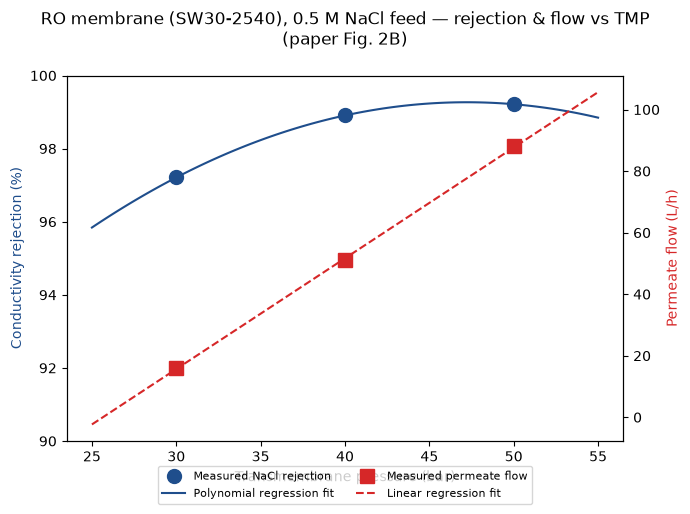

In [10]:
fig, ax1 = plt.subplots(figsize=(7,5))
ax1.plot(cal.TMP_bar, y, "o", color="#1f4e8c", ms=10, label="Measured NaCl rejection")
ax1.plot(tmp_grid, rej_grid, "-", color="#1f4e8c", label="Polynomial regression fit")
ax1.set_xlabel("Transmembrane pressure (bar)")
ax1.set_ylabel("Conductivity rejection (%)", color="#1f4e8c")
ax1.set_ylim(90,100)
ax2 = ax1.twinx()
ax2.plot(cal.TMP_bar, yflux, "s", color="#d62728", ms=10, label="Measured permeate flow")
ax2.plot(tmp_grid, flux_grid, "--", color="#d62728", label="Linear regression fit")
ax2.set_ylabel("Permeate flow (L/h)", color="#d62728")
fig.suptitle("RO membrane (SW30-2540), 0.5 M NaCl feed — rejection & flow vs TMP\n(paper Fig. 2B)")
fig.legend(loc="lower center", ncol=2, bbox_to_anchor=(0.5,-0.02), fontsize=8)
plt.tight_layout()
plt.savefig("plots/model2_ro_rejection.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
with open("models/metrics_ro_rejection.txt","w") as f:
    f.write(f"Rejection LOOCV R2={r2_rej:.3f}\n")
    f.write(f"Permeate flow LOOCV R2={r2_flux:.3f}\n")
    f.write("Note: only 3 calibration pressures (30/40/50 bar) available in source data;\n")
    f.write("polynomial degree kept low (2) to avoid overfitting on n=3.\n")
    f.write(f"At 50 bar (operating point), predicted rejection = {poly_model.predict([[50]])[0]:.2f}% "
            f"(paper reports 99.2% at 50 bar in the individual test).\n")
print("done")

done
